In [1]:
import matplotlib
matplotlib.rcParams['font.serif'] = ['Times'] + matplotlib.rcParams['font.serif']
matplotlib.rcParams['font.size'] = 6
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams["ps.usedistiller"] = 'xpdf'
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.weight'] = 'normal'
matplotlib.rcParams["mathtext.fontset"] = 'cm'

In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

import random
import math

import pandas as pd

import copy

import cvxpy
cp = cvxpy

import figurefirst as fifi

from braid_analysis import braid_analysis_plots
from braid_analysis import flymath
import fly_plot_lib.plot as fpl

import pynumdiff

import scipy.stats

In [3]:
np.random.seed(42)

In [4]:
from braid_analysis.flymath import wrap_angle, unwrap_angle

In [5]:
# Time
dt = 0.01 # sec
T = 28 # sec 
surge_T = 2 # sec
wind_condition_T = 6 # sec

# Circular basis
omega = 4 # rad/sec
b = 0

# Parameters for determining lambda
alpha = 8
mu = 0.1

# Paramter for translation
beta = 0.2

# Ground speed
speed = 0.3

# Window for determining vector strengh
window_size_vector_strength = 100 # time steps

# Saccadic trajectory
SMOOTHING_WINDOW = 11
SACCADE_THRESHOLD_PROPORTIONAL = 8 
SACCADE_THRESHOLD_DERIVATIVE = 3

In [6]:
def get_noisy_wind_speed_and_direction(wind_condition_T, speed_mean, speed_std, dir_mean, dir_std,
                                      style='random_walk'):
    '''
    style: random_walk, or 'gaussian'
    '''
    L = int(wind_condition_T/dt)
    wind_speed = np.abs(np.random.normal(speed_mean, speed_std, L))
    wind_speed, _ = pynumdiff.savgoldiff(wind_speed, dt, [3, 11, 11])
    
    
    if style == 'random_walk':
        wind_direction = wrap_angle(np.random.normal(0, dir_std, L))
        wind_direction = np.cumsum(wind_direction) + dir_mean
    elif style != 'gaussian':
        raise ValueError('style must be gaussian or random_walk')
    else:
        wind_direction = wrap_angle(np.random.normal(dir_mean, dir_std, L))
    wind_direction_x = np.cos(wind_direction)
    wind_direction_y = np.sin(wind_direction)
    
    wind_direction_x, _ = pynumdiff.savgoldiff(wind_direction_x, dt, [3, 11, 11])
    wind_direction_y, _ = pynumdiff.savgoldiff(wind_direction_y, dt, [3, 11, 11])
    
    wind_direction = np.arctan2(wind_direction_y, wind_direction_x)

    return wind_speed, wind_direction

# Circular motif

In [7]:
t = np.arange(0, T, dt)
psi = omega*t + b
psi = wrap_angle(psi)
Psi = np.array([[np.sin(psi[i]), np.cos(psi[i])] for i in range(len(psi))])
print(Psi)

[[ 0.          1.        ]
 [ 0.03998933  0.99920011]
 [ 0.07991469  0.99680171]
 ...
 [-0.93818039  0.34614673]
 [-0.92358777  0.38338705]
 [-0.9075176   0.42001405]]


# Wind time series

## Explore (laminar wind)

In [8]:
wind_speed, wind_direction = get_noisy_wind_speed_and_direction(surge_T, 0.5, 0.02, np.pi, 0.2, style='gaussian')

explore_laminar_wind = {'wind_speed': wind_speed,
                'wind_direction': wind_direction,
                'wind_type': ['laminar']*len(wind_speed),
                       'behavior': ['explore']*len(wind_speed),}
explore_laminar_wind_df = pd.DataFrame(explore_laminar_wind)

## Surge (laminar wind)

In [9]:
wind_speed, wind_direction = get_noisy_wind_speed_and_direction(surge_T, 0.5, 0.02, np.pi, 0.2, style='gaussian')

surge_laminar_wind = {'wind_speed': wind_speed,
                'wind_direction': wind_direction,
                'wind_type': ['laminar']*len(wind_speed),
                       'behavior': ['surge']*len(wind_speed)}
surge_laminar_wind_df = pd.DataFrame(surge_laminar_wind)

## Laminar wind chunk

In [10]:
wind_speed, wind_direction = get_noisy_wind_speed_and_direction(wind_condition_T, 0.5, 0.02, np.pi, 0.2, style='gaussian')



laminar_wind = {'wind_speed': wind_speed,
                'wind_direction': wind_direction,
                'wind_type': ['laminar']*len(wind_speed),
                       'behavior': ['search']*len(wind_speed)}
laminar_wind_df = pd.DataFrame(laminar_wind)

## Low wind chunk

In [11]:
wind_speed, wind_direction = get_noisy_wind_speed_and_direction(wind_condition_T, 0.22, 0.1, np.pi, 1, style='gaussian')

low_wind = {'wind_speed': wind_speed,
                'wind_direction': wind_direction,
                'wind_type': ['low']*len(wind_speed),
                       'behavior': ['search']*len(wind_speed)}
low_wind_df = pd.DataFrame(low_wind)

## Unsteady wind chunk

In [12]:
wind_speed, wind_direction = get_noisy_wind_speed_and_direction(wind_condition_T, 0.3, 0.5, np.pi, 0.3)


unsteady_wind = {'wind_speed': wind_speed,
                'wind_direction': wind_direction,
                'wind_type': ['unsteady']*len(wind_speed),
                       'behavior': ['search']*len(wind_speed)}
unsteady_wind_df = pd.DataFrame(unsteady_wind)

## Still air chunk

In [13]:
wind_speed, wind_direction = get_noisy_wind_speed_and_direction(wind_condition_T, 0, 0.02, np.pi, 0.5)


still_wind = {'wind_speed': wind_speed,
                'wind_direction': wind_direction,
                'wind_type': ['still']*len(wind_speed),
                       'behavior': ['search']*len(wind_speed)}
still_wind_df = pd.DataFrame(still_wind)

## Combined

In [14]:
wind_df = pd.concat([explore_laminar_wind_df,
                     surge_laminar_wind_df,
                     laminar_wind_df,
                     #moderate_wind_df,
                     unsteady_wind_df,
                     low_wind_df,
                     still_wind_df], ignore_index=True)

## Light smoothing

In [15]:
wind_df.wind_speed, _ = pynumdiff.savgoldiff(wind_df.wind_speed.values, dt, [3,7,7])
wind_direction_x = np.cos(wind_df.wind_direction.values)
wind_direction_y = np.sin(wind_df.wind_direction.values)
wind_direction_x, _ = pynumdiff.savgoldiff(wind_direction_x, dt, [3,7,7])
wind_direction_y, _ = pynumdiff.savgoldiff(wind_direction_y, dt, [3,7,7])
wind_df.wind_direction = np.arctan2(wind_direction_y, wind_direction_x)

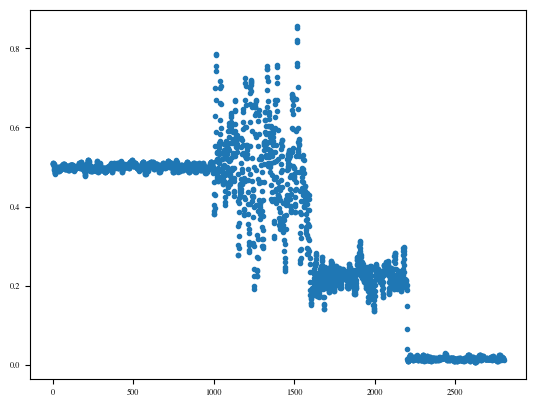

In [16]:
plt.plot(wind_df.wind_speed.values, '.')

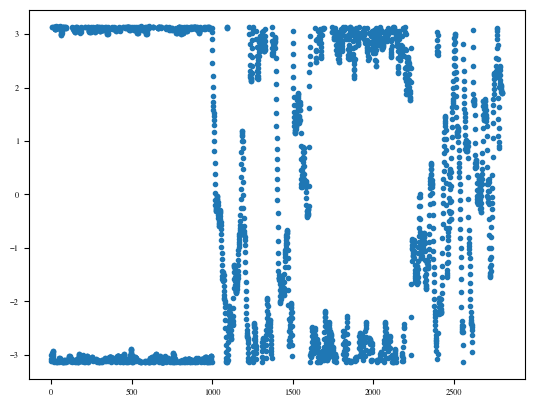

In [17]:
plt.plot(wind_df.wind_direction.values, '.')

## Perpendicular wind direction

In [18]:
wind_df['perpendicular_wind_direction'] = wrap_angle(wind_df.wind_direction + np.pi/2)

# Affine transform

## Minor axis, lambda

In [19]:
def sigma(z):
    return 1 / (1 + np.exp(-alpha*(z-mu)))

def vec_str(wind_df, index):
    last_ix = index
    first_ix = np.max([0, index-window_size_vector_strength])
    wind_df_subset = wind_df.loc[first_ix:last_ix]
    wind_df_subset_x = wind_df_subset.wind_speed*np.cos(wind_df_subset.wind_direction)
    wind_df_subset_y = wind_df_subset.wind_speed*np.sin(wind_df_subset.wind_direction)
    wind_xy = np.vstack((wind_df_subset_x, wind_df_subset_y))
    vec_str = np.linalg.norm(np.sum(wind_xy, axis=1)) / len(wind_df_subset_x)
    return vec_str

def lam(vec_str):
    return 1 - sigma(vec_str)

In [20]:
vec_strs = [vec_str(wind_df, index) for index in range(len(wind_df))]
lambdas = [lam(vec_strs[index]) for index in range(len(wind_df))]

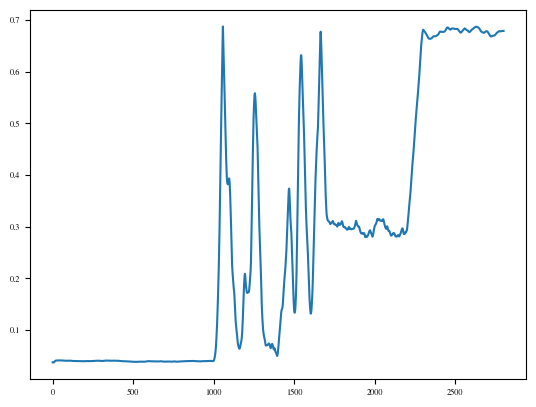

In [21]:
plt.plot(lambdas)

In [22]:
len(lambdas)

2800

## Rotation matrix

In [23]:
def get_R(perpendicular_wind_direction, index):
    R = np.array([[np.cos(perpendicular_wind_direction[index]), -np.sin(perpendicular_wind_direction[index])],
                  [np.sin(perpendicular_wind_direction[index]), np.cos(perpendicular_wind_direction[index])]])
    return R

Rs = [get_R(wind_df.perpendicular_wind_direction.values, i) for i in range(len(wind_df.perpendicular_wind_direction.values))]

## Scaling matrix

In [24]:
scale = []
for b in wind_df.behavior.values:
    if b == 'search':
        scale.append(1)
    else:
        scale.append(0.01)
scale = np.array(scale)

In [25]:
def get_S(lambdas, index):
    S = scale[index]*np.diag([1, lambdas[index]])
    return S

Ss = [get_S(lambdas, i) for i in range(len(lambdas))]

## RSR^T

In [26]:
RSRT = [Rs[i]@Ss[i]@Rs[i].T for i in range(len(lambdas))]

## Rotated and scaled course direction

In [27]:
Psi_check = [Psi[i:i+1,:]@RSRT[i].T for i in range(len(lambdas))]

## Translation

In [28]:
goal = []
for i, b in enumerate(wind_df.behavior.values):
    if b == 'explore':
        if i < 100:
            goal.append(60*np.pi/180)
        else:
            goal.append(-70*np.pi/180)
    elif b == 'surge':
        goal.append(wind_df.wind_direction.values[i] + np.pi)
    else:
        goal.append(wind_df.wind_direction.values[i] + np.pi)
goal = np.array(goal)

In [29]:
tx = beta*(np.log10(1/scale)+1)*(1-np.array(lambdas))*np.cos(goal)
ty = beta*(np.log10(1/scale)+1)*(1-np.array(lambdas))*np.sin(goal)

Ts = [np.array([[1, 0, tx[i]],
              [0, 1, ty[i]],
              [0, 0, 1]]) for i in range(len(lambdas))]

In [30]:
Psi_check_padded = [ np.hstack([Psi_check[i], np.array([[1]])]) for i in range(len(lambdas))]

In [31]:
Psi_hat_padded = [Psi_check_padded[i]@Ts[i].T for i in range(len(lambdas))]

In [32]:
Psi_hat = np.vstack(Psi_hat_padded)[:,0:2]

# Final affine transformed course

In [33]:
course_x = Psi_hat[:,0]
course_y = Psi_hat[:,1]

course = np.arctan2(course_y, course_x)

In [34]:
vx = course_x*speed
vy = course_y*speed

x = np.cumsum(vx)*dt
y = np.cumsum(vy)*dt

# Saccadic version

In [35]:
def get_upwind_biased_trajec_saccade(course_angle,
                                     SMOOTHING_WINDOW, 
                                     SACCADE_THRESHOLD_PROPORTIONAL, 
                                     SACCADE_THRESHOLD_DERIVATIVE):
    
    unwrapped_course_angle = flymath.unwrap_angle(course_angle, correction_window_for_2pi=40)
    _, unwrapped_course_angle_diff = pynumdiff.savgoldiff(unwrapped_course_angle, dt, [3, SMOOTHING_WINDOW, SMOOTHING_WINDOW])

    threshold = SACCADE_THRESHOLD_PROPORTIONAL
    staircase_approx = [unwrapped_course_angle[0]]
    error = 0
    for i in range(1, len(unwrapped_course_angle)):
        error += unwrapped_course_angle[i] - staircase_approx[-1]
        if np.abs(error) > threshold:
            staircase_approx.append(unwrapped_course_angle[i] + unwrapped_course_angle_diff[i]*SACCADE_THRESHOLD_DERIVATIVE*dt)
            error = 0
        else:
            staircase_approx.append(staircase_approx[-1])
    
    staircase_warped_course_angle = np.array(staircase_approx)
    
    staircase_warped_course_x = np.cos(staircase_warped_course_angle)
    staircase_warped_course_y = np.sin(staircase_warped_course_angle)
    
    staircase_warped_course_x, _ = pynumdiff.savgoldiff(staircase_warped_course_x, dt, [3, SMOOTHING_WINDOW, SMOOTHING_WINDOW])
    staircase_warped_course_y, _ = pynumdiff.savgoldiff(staircase_warped_course_y, dt, [3, SMOOTHING_WINDOW, SMOOTHING_WINDOW])
    staircase_warped_course_angle = np.arctan2(staircase_warped_course_y, staircase_warped_course_x)

    return staircase_warped_course_x, staircase_warped_course_y, staircase_warped_course_angle

In [36]:
staircase_warped_course_x, staircase_warped_course_y, course_sac = get_upwind_biased_trajec_saccade(course,
                                     SMOOTHING_WINDOW, 
                                     SACCADE_THRESHOLD_PROPORTIONAL, 
                                     SACCADE_THRESHOLD_DERIVATIVE)

In [37]:
vx_sac = np.cos(course_sac)*speed*0.53
vy_sac = np.sin(course_sac)*speed*0.53

x_sac = np.cumsum(vx_sac)*dt
y_sac = np.cumsum(vy_sac)*dt

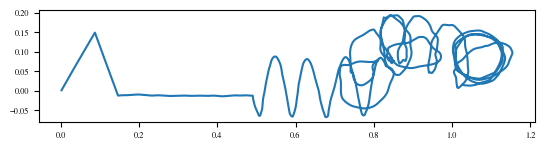

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x,y)
ax.set_aspect('equal')

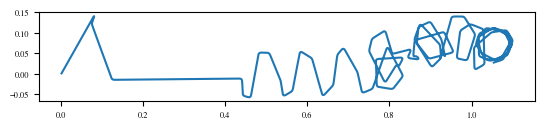

In [39]:
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x_sac,y_sac)
ax.set_aspect('equal')

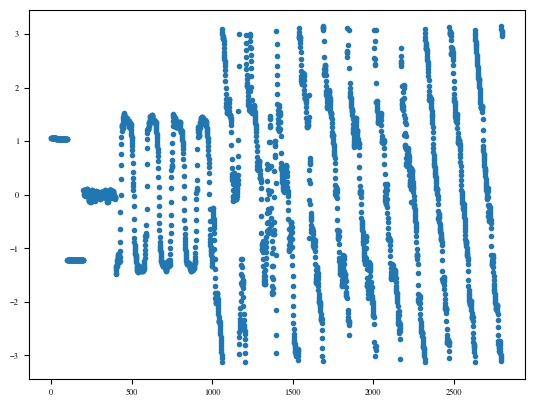

In [40]:
plt.plot(course, '.')

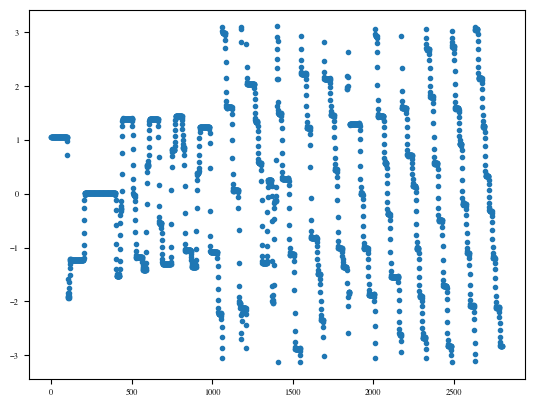

In [41]:
plt.plot(course_sac, '.')

/opt/anaconda3/envs/Python311/lib/python3.11/site-packages/pynumdiff/polynomial_fit/_polynomial_fit.py:132: UserWarning: Kernel window size should be odd. Added 1 to length.
  warn("Kernel window size should be odd. Added 1 to length.")


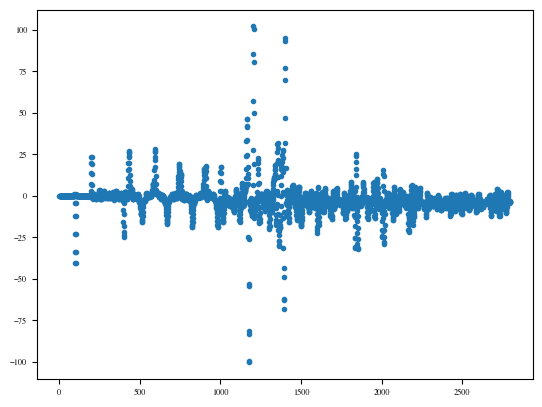

In [42]:
course_x = Psi_hat[:,0]
course_y = Psi_hat[:,1]

course_x_smooth, course_x_diff = pynumdiff.savgoldiff(course_x, dt, [3, 3, 3])
course_y_smooth, course_y_diff = pynumdiff.savgoldiff(course_y, dt, [3, 3, 3])

course_smooth = np.arctan2(course_y_smooth, course_x_smooth)

unwrapped_course_angle = flymath.unwrap_angle(course_smooth, correction_window_for_2pi=100)
_, unwrapped_course_angle_diff = pynumdiff.savgoldiff(unwrapped_course_angle, dt, [3, 11, 11])

plt.plot(unwrapped_course_angle_diff, '.')


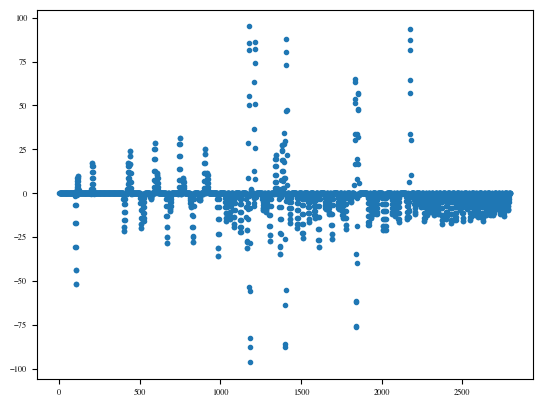

In [43]:
course_x_sac = np.cos(course_sac)
course_y_sac = np.sin(course_sac)

course_x_smooth, course_x_diff = pynumdiff.savgoldiff(course_x_sac, dt, [3, 3, 3])
course_y_smooth, course_y_diff = pynumdiff.savgoldiff(course_y_sac, dt, [3, 3, 3])

course_smooth_sac = np.arctan2(course_y_smooth, course_x_smooth)

unwrapped_course_angle_sac = flymath.unwrap_angle(course_smooth_sac, correction_window_for_2pi=100)
_, unwrapped_course_angle_diff_sac = pynumdiff.savgoldiff(unwrapped_course_angle_sac, dt, [3, 11, 11])

plt.plot(unwrapped_course_angle_diff_sac, '.')

In [44]:
unifying_sim_df = pd.DataFrame({'time': t,
                                'circular_basis': psi,
                                'circular_basis_x': np.cos(psi),
                                'circular_basis_y': np.sin(psi),
                                'wind_speed': wind_df.wind_speed,
                                'wind_direction': wind_df.wind_direction,
                                'wind_type': wind_df.wind_type,
                                'behavior': wind_df.behavior,
                                'wind_vec_str': np.array(vec_strs),
                                'lambda': np.array(lambdas),
                                'scale': scale,
                                'goal': wrap_angle(goal),
                                'x': x,
                                'y': y,
                                'course': course,
                                'course_x': course_x,
                                'course_y': course_y,
                                'angvel': unwrapped_course_angle_diff,
                                'x_sac': x_sac,
                                'y_sac': y_sac,
                                'course_sac': course_sac,
                                'course_x_sac': staircase_warped_course_x,
                                'course_y_sac': staircase_warped_course_y,
                                'omega': omega*np.ones_like(course),
                                'angvel_sac': unwrapped_course_angle_diff_sac,
                               })
                                

In [45]:
unifying_sim_df.to_parquet('unifying_sim_data.parquet')